In [ ]:
"""
============================================================================
Author          : Mohammad Norizadeh Cherloo
Website         : https://onlinebme.com/
GitHub          : https://github.com/Mohammad-Norizadeh-Cherloo
Google Scholar  : https://scholar.google.com/citations?user=fIKpYm8AAAAJ

Project         : Air Quality Prediction (UCI Dataset) - Time Series Regression
Algorithm       : Long Short-Term Memory (LSTM) Network – completely from scratch

Description     : Full manual implementation of an LSTM network without using 
                  any high-level recurrent layers (nn.LSTM, nn.RNN, etc.).

                  Implemented components from scratch:
                  - LSTM cell with Forget, Input, Cell, and Output gates
                  - Xavier and Orthogonal weight initialization
                  - Forward propagation through time
                  - Backpropagation Through Time (BPTT)
                  - Gradient clipping (optional)
                  - SGD-based parameter update

                  Applied to the UCI Air Quality dataset for multi-step 
                  time series regression.

                  Part of the comprehensive Deep Learning course.

Full video course (theory + equations + step-by-step implementation):
https://onlinebme.com/
https://onlinebme.com/product/implementing-neural-networks-with-pytorch/
============================================================================
"""

import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np


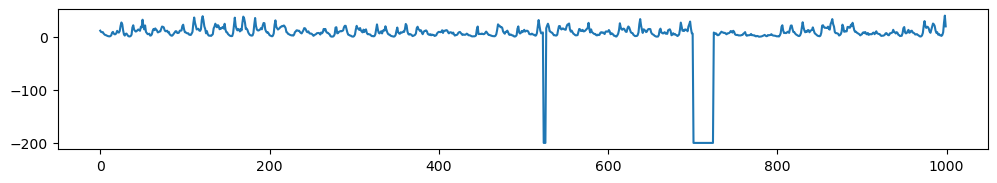

In [12]:
#%% load dataset 
filename= r'AirQualityUCI.xlsx'
df= pd.read_excel(filename)

# print(df.tail(5))
names= df.columns
target= df.iloc[:,5].to_numpy()
df= df.drop(names[5], axis=1)
data= df.iloc[:,2:].to_numpy()

data[np.isnan(data)]=0
target[np.isnan(target)]=0

plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(target[:1000])
plt.show()

In [13]:
Xtrain,Xtest,y_train,y_test=train_test_split(data,target,
                                                 train_size=0.7,
                                                 shuffle=False)

In [14]:
# standardize
scaler= prep.StandardScaler()
Xtrain= scaler.fit_transform(Xtrain)
Xtest= scaler.transform(Xtest)

In [15]:
def sequence_data(data,target,step):
    tau= step
    data_seq=[]
    target_seq= []
    for i in range(tau,data.shape[0],1):
        d= data[i-tau:i]
        y= target[i-tau:i]
        data_seq.append(d)
        target_seq.append(y)
        # print(i)
    data_seq = np.array(data_seq)
    target_seq = np.array(target_seq)
    return data_seq,target_seq

Xtrain_seq,y_train_seq= sequence_data(Xtrain,y_train,step=5)
Xtest_seq,y_test_seq= sequence_data(Xtest,y_test,step=5)
print(Xtrain_seq.shape,y_train_seq.shape)
print(Xtest_seq.shape,y_test_seq.shape)

(6544, 5, 12) (6544, 5)
(2803, 5, 12) (2803, 5)


In [16]:
#%% convert to tensor
Xtrain= torch.from_numpy(Xtrain_seq).type(torch.float32)
y_train= torch.from_numpy(y_train_seq).type(torch.float32)

Xtest= torch.from_numpy(Xtest_seq).type(torch.float32)
y_test= torch.from_numpy(y_test_seq).type(torch.float32)

In [17]:
def xavier_init(shape):
    fan_in, fan_out = shape[1], shape[0]
    # limit = torch.sqrt(torch.tensor(6.0 / (fan_in + fan_out)))
    # w= torch.empty(shape).uniform_(-limit, limit)
    sigma= torch.sqrt(torch.tensor(2 / (fan_in + fan_out)))
    w= torch.randn(shape)*sigma
    return w
def orthogonal_init(shape):
    # shape = (n_hidden, n_hidden)
    W = torch.randn(shape)
    q, r = torch.linalg.qr(W)
    # Ensure determinant is positive (for orthogonal)
    if torch.det(q) < 0:
        q[:, 0] = -q[:, 0]
    return q

class LSTMManual():
    def __init__(self, n_features, n_hidden, n_out, 
                 lr=0.001,
                 wrate=1.0):
        # dims
        self.n_features = n_features
        self.n_hidden = n_hidden
        self.n_out = n_out
        self.lr = lr

        # Input-to-gate weights (W), shape (n_hidden, n_features)
        self.Wf = xavier_init((n_hidden, n_features) )
        self.Wi = xavier_init((n_hidden, n_features) )
        self.Wg = xavier_init((n_hidden, n_features) )
        self.Wo = xavier_init((n_hidden, n_features)) 
        # Hidden-to-gate weights (U), shape (n_hidden, n_hidden)
        self.Uf = orthogonal_init((n_hidden, n_hidden))
        self.Ui = orthogonal_init((n_hidden, n_hidden))
        self.Ug = orthogonal_init((n_hidden, n_hidden)) 
        self.Uo = orthogonal_init((n_hidden, n_hidden))

        # biases (n_hidden, 1)
        self.bf = torch.zeros(n_hidden, 1)
        self.bi = torch.zeros(n_hidden, 1)
        self.bg = torch.zeros(n_hidden, 1) 
        self.bo = torch.zeros(n_hidden, 1)

        # Output layer parameters (n_out, n_hidden)
        self.wy = xavier_init((n_out, n_hidden) )
        self.by = xavier_init((n_out, 1))

        # Grad accumulators (same shapes)
        self.dWf = torch.zeros_like(self.Wf)
        self.dWi = torch.zeros_like(self.Wi)
        self.dWg = torch.zeros_like(self.Wg)
        self.dWo = torch.zeros_like(self.Wo)

        self.dUf = torch.zeros_like(self.Uf)
        self.dUi = torch.zeros_like(self.Ui)
        self.dUg = torch.zeros_like(self.Ug)
        self.dUo = torch.zeros_like(self.Uo)

        self.dbf = torch.zeros_like(self.bf)
        self.dbi = torch.zeros_like(self.bi)
        self.dbg = torch.zeros_like(self.bg)
        self.dbo = torch.zeros_like(self.bo)

        self.dwy = torch.zeros_like(self.wy)
        self.dby = torch.zeros_like(self.by)

    # --- call/forward API similar to your RNN ---
    def __call__(self, x, h0=None, c0=None):
        return self.forward(x, h0, c0)

    def forward(self, x, h0=None, c0=None):
        batch_size, T, _ = x.size()
        n_h = self.n_hidden

        # initialize
        if h0 is None:
            h_prev = torch.zeros(n_h, batch_size)
        else:
            h_prev = h0  # assumed shape (n_hidden, batch_size)
        if c0 is None:
            c_prev = torch.zeros(n_h, batch_size)
        else:
            c_prev = c0

        yos = []
        # hts = []
        # We'll save per-timestep values needed for backprop
        saved = {
            "x": [],       # xt (n_features, batch)
            "h_prev": [],  # h_{t-1}
            "c_prev": [],  # c_{t-1}
            "f": [], "i": [], "g": [], "o": [], "c": [], "h": []
        }

        for t in range(T):
            xt = x[:, t, :].T   # (n_f, b_s)
            # gate pre-activations and activations
            zf = self.Wf @ xt + self.Uf @ h_prev + self.bf   # (n_h, b_s)
            zi = self.Wi @ xt + self.Ui @ h_prev + self.bi
            zg = self.Wg @ xt + self.Ug @ h_prev + self.bg
            zo = self.Wo @ xt + self.Uo @ h_prev + self.bo

            f_t = torch.sigmoid(zf)# (n_h, b_s)
            i_t = torch.sigmoid(zi)
            g_t = torch.tanh(zg)
            o_t = torch.sigmoid(zo)

            c_t = f_t * c_prev + i_t * g_t # (n_h, b_s)
            tanh_c_t = torch.tanh(c_t) # (n_h, b_s)
            h_t = o_t * tanh_c_t # (n_h, b_s)

            vout = self.wy @ h_t + self.by# (n_out, b_size)
            y_t = (vout)

            # save
            yos.append(y_t)
            # hts.append(h_t)
            # saved["x"].append(xt)
            saved["h_prev"].append(h_prev)
            saved["c_prev"].append(c_prev)
            saved["f"].append(f_t)
            saved["i"].append(i_t)
            saved["g"].append(g_t)
            saved["o"].append(o_t)
            saved["c"].append(c_t)
            saved["h"].append(h_t)

            # step
            h_prev = h_t
            c_prev = c_t

        return yos,saved

    # --- Backprop through time (manual) ---
    def backward(self, x, y_true, y_pred_list, saved):
        # x= saved['x'] 
        h_prev_list= saved["h_prev"] 
        c_prev_list= saved["c_prev"]
        f= saved["f"]
        i= saved["i"]
        g= saved["g"]
        o= saved["o"]
        c= saved["c"]
        h= saved["h"]
        
        n_hidden= self.n_hidden
        b_size,T,_= x.size()
        
        
        
        dh_next= torch.zeros(b_size,n_hidden)
        dc_next= torch.zeros(b_size,n_hidden)
        for t in reversed(range(T)):
            xt= x[:,t,:]#  b_s * n_f
            ft= f[t].T # (n_h, b_s)
            it= i[t].T
            ot= o[t].T
            gt= g[t].T
            ct= c[t].T
            ht= h[t].T
            c_prev=c_prev_list[t].T
            h_prev=h_prev_list[t].T
            y_t= y_pred_list[t] # n_out x b_s 
            d_t=  y_true[:,t].T# n_out x b_s 
            
            gdo= self.g_linear(y_t)
            delta_o= (d_t-y_t)*gdo # n_out x b_s 
            self.dwy+= delta_o@ ht # n_out x b_s 
            self.dby+= torch.sum(delta_o,dim=1,keepdim=True)# n_out x 1
            # dh from output and next step

            dht = delta_o.T @ self.wy + dh_next
            dct = dht * ot * (1 - torch.tanh(ct)**2) + dc_next
            
            # b_s x n_h
           
            dft= dct * (c_prev)
            dit= dct* (gt)
            dot= dht* (torch.tanh(ct))
            dgt= dct * (it)

            
            dzf= (dft * (ft*(1-ft))).T
            dzi= (dit * (it*(1-it))).T
            dzo= (dot * (ot*(1-ot))).T
            dzg= (dgt * ((1-gt**2))).T
            
            
            self.dWf+= dzf @ xt
            self.dWi+= dzi @ xt
            self.dWo+= dzo @ xt
            self.dWg+= dzg @ xt
            
            self.dUf+= dzf @ h_prev
            self.dUi+= dzi @ h_prev
            self.dUo+= dzo @ h_prev
            self.dUg+= dzg @ h_prev
            
            
            self.dbf += torch.sum(dzf, dim=1, keepdims=True)
            self.dbi += torch.sum(dzi, dim=1, keepdims=True)
            self.dbo += torch.sum(dzo, dim=1, keepdims=True)
            self.dbg += torch.sum(dzg, dim=1, keepdims=True)
            
            dh_next = ( dzf.T @ self.Uf) + (dzi.T @ self.Ui) +(dzo.T @ self.Uo) + (dzg.T @ self.Ug)

            dc_next = dct * ft
        
        # clipping by average
        self.dWf/=(b_size*T)
        self.dWi/=(b_size*T)
        self.dWg/=(b_size*T)
        self.dWo/=(b_size*T)

        self.dUf/=(b_size*T)
        self.dUi/=(b_size*T)
        self.dUg/=(b_size*T)
        self.dUo/=(b_size*T)

        self.dbf/=(b_size*T)
        self.dbi/=(b_size*T)
        self.dbg/=(b_size*T)
        self.dbo/=(b_size*T)

        self.dwy/=(b_size*T)
        self.dby/=(b_size*T)
              
    # reset grads
    def zero_grad(self):
        self.dWf.zero_()
        self.dWi.zero_()
        self.dWg.zero_()
        self.dWo.zero_()

        self.dUf.zero_()
        self.dUi.zero_()
        self.dUg.zero_()
        self.dUo.zero_()

        self.dbf.zero_()
        self.dbi.zero_()
        self.dbg.zero_()
        self.dbo.zero_()

        self.dwy.zero_()
        self.dby.zero_()
        
    def clipping(self,grad_clip_val):
          params= [self.dWf,self.dWi,self.dWg,self.dWo,
            self.dUf,self.dUi,self.dUg,self.dUo,
            self.dbf,self.dbi,self.dbg,self.dbo,
            self.dwy,self.dby]
          norm = torch.sqrt(sum(torch.sum((p ** 2)) for p in params))
          if norm > grad_clip_val:
               for param in params:
                    param.mul_(grad_clip_val / norm) 
        
    # SGD-like step (add gradients scaled by lr)
    def step(self):
        self.Wf += self.lr * self.dWf
        self.Wi += self.lr * self.dWi
        self.Wg += self.lr * self.dWg
        self.Wo += self.lr * self.dWo

        self.Uf += self.lr * self.dUf
        self.Ui += self.lr * self.dUi
        self.Ug += self.lr * self.dUg
        self.Uo += self.lr * self.dUo

        self.bf += self.lr * self.dbf
        self.bi += self.lr * self.dbi
        self.bg += self.lr * self.dbg
        self.bo += self.lr * self.dbo

        self.wy += self.lr * self.dwy
        self.by += self.lr * self.dby

    def mse(self, y_true, y_pred):
        # y_true: (batch, n_out), y_pred: list of outputs (n_out, batch)
        y_true_T = y_true[:,-1].T
        y_pred_last = y_pred[-1]
        e = y_true_T - y_pred_last
        return torch.mean(e ** 2)
     
    def g_tanh(self,y):
        return (1-y**2)

    def g_sigmoid(self,y):
        return y*(1-y)

    def g_relu(self,y):
        yhat= (y>0).type(torch.float32)
        return yhat

    def g_linear(self,y):
        return torch.ones(y.size())


In [18]:
#% build data loader 
ds= TensorDataset(Xtrain,y_train)
train_loader= DataLoader(ds,batch_size=32,
                         shuffle=False,
                         drop_last=True)

In [19]:
#%% train Neural Network
torch.manual_seed(1)
lr=0.01
n_out= 1
n_hid1= 85

n_features=Xtrain_seq.shape[2]
mdl = LSTMManual(n_features, 
                 n_hid1, n_out, 
                 lr=lr)

In [20]:
mse=[]
epoch=20
h0=None
c0= None
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          # farward pass
          ypred_list, saved = mdl.forward(xbatch,h0,c0)
          h0= saved['h'][-1]
          c0= saved['c'][-1]
          loss = mdl.mse(ybatch, ypred_list)
          mdl.backward(xbatch, ybatch, ypred_list, saved)
          # mdl.clipping(1)
          mdl.step()
          mdl.zero_grad()

          er.append(loss)
          # er.append(mdl.mse(ybatch[-1],ypred_list[-1])) 

     loss= torch.mean(torch.tensor(er))
     mse.append(loss)
     print(f'MSE({iter}): {mse[iter]:.8f}')

mse=torch.tensor(mse)

MSE(0): 289.44912720
MSE(1): 8.56179714
MSE(2): 7.80521393
MSE(3): 4.20256615
MSE(4): 2.75195098
MSE(5): 2.89996409
MSE(6): 1.36413610
MSE(7): 1.09714150
MSE(8): 0.82108903
MSE(9): 0.52014697
MSE(10): 0.43048239
MSE(11): 0.37573650
MSE(12): 0.32711354
MSE(13): 0.29389083
MSE(14): 0.26527694
MSE(15): 0.24233429
MSE(16): 0.22252363
MSE(17): 0.20457567
MSE(18): 0.19012380
MSE(19): 0.17733297


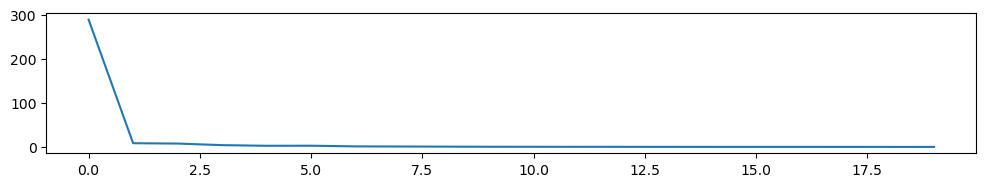

In [21]:
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(mse)
plt.show()

In [22]:
#%% test trained Neural Network
ypred=[]
h0=None
c0=None
for i in range(Xtest.size(0)):
    xt= Xtest[i]
    xt= xt.unsqueeze(0)
    # yp= mdl(xt)[0]
    ypred_list, saved = mdl.forward(xt,h0,c0)
    h0= saved['h'][-1]
    c0= saved['c'][-1]
    yp=ypred_list[-1]
    # yp= torch.argmax(yp.T,dim=1)
    ypred.append(yp)

ypred= np.array(ypred)

In [23]:
ypred.shape

(2803, 1, 1)

In [24]:
ypred=ypred.flatten()
d_test= y_test[:,-1].flatten()

print(ypred.shape,d_test.shape,Xtest.shape,yp[-1].shape,Xtest[i].shape)

(2803,) torch.Size([2803]) torch.Size([2803, 5, 12]) torch.Size([1]) torch.Size([5, 12])


MSE:3.181
MAE:1.309
R square:0.999


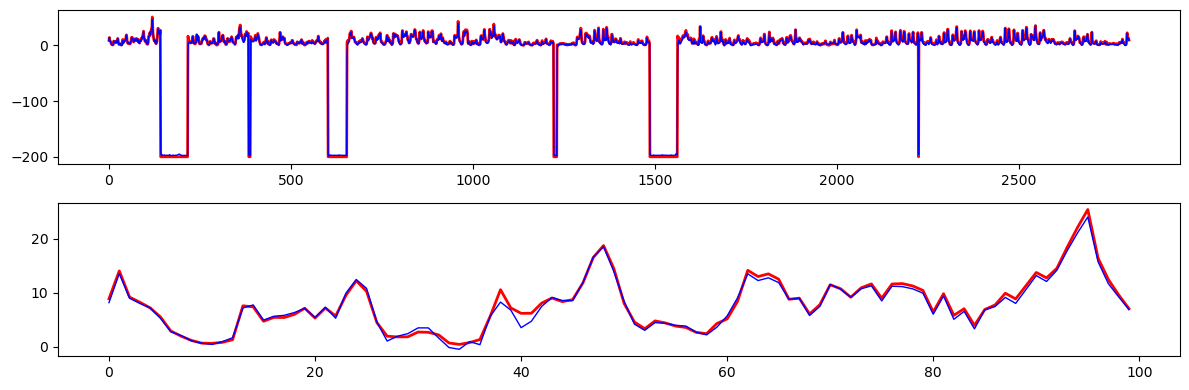

In [25]:
#%% validate your Neural Network
MSE= metrics.mean_squared_error(d_test,ypred)
MAE= metrics.mean_absolute_error(d_test,ypred)
r2= metrics.r2_score(d_test,ypred)

# input= torch.cat((d_test.reshape(1,-1),ypred.reshape(1,-1)),dim=0)
# cr= torch.corrcoef(input)
# corr= cr[0,1]
print(f'MSE:{MSE:.3f}')
print(f'MAE:{MAE:.3f}')
print(f'R square:{r2:.3f}')
# print(f'correlation:{corr:.3f}')

plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(d_test,'r',linewidth=2)
plt.plot(ypred,'b',linewidth=1)
plt.subplot(2,1,2)
plt.plot(d_test[:100],'r',linewidth=2)
plt.plot(ypred[:100],'b',linewidth=1)
plt.tight_layout()
plt.show()